In [6]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import time # Importamos time para controlar la velocidad y no bloquear la API

# Configuración visual
%matplotlib inline
sns.set_theme(style="whitegrid")

API_KEY = "170265dcc664b1396cd1d6be03d32bc0"

# Lista manual expandida con muchas ciudades para hacer la base grande
ciudades = [
    # América del Sur
    "Lima", "Arequipa", "Trujillo", "Cusco", "Iquitos", "Piura", "Chiclayo", "Huancayo", "Tacna", "Pucallpa",
    "Buenos Aires", "Cordoba", "Rosario", "Mendoza", "Santiago", "Valparaiso", "Concepcion",
    "Bogota", "Medellin", "Cali", "Cartagena", "Quito", "Guayaquil", "La Paz", "Santa Cruz de la Sierra",
    "Brasilia", "Sao Paulo", "Rio de Janeiro", "Salvador", "Caracas", "Montevideo", "Asuncion",
    # América del Norte
    "New York", "Los Angeles", "Chicago", "Miami", "Houston", "Toronto", "Vancouver", "Mexico City", "Guadalajara", "Monterrey",
    # Europa
    "Madrid", "Barcelona", "Valencia", "Seville", "London", "Manchester", "Paris", "Marseille",
    "Berlin", "Munich", "Hamburg", "Rome", "Milan", "Naples", "Amsterdam", "Brussels", "Zurich", "Vienna",
    "Lisbon", "Porto", "Moscow", "Saint Petersburg", "Kyiv", "Warsaw", "Prague", "Budapest", "Athens", "Istanbul",
    # Asia y Oceanía
    "Tokyo", "Osaka", "Seoul", "Beijing", "Shanghai", "Hong Kong", "Bangkok", "Singapore", "Jakarta", 
    "New Delhi", "Mumbai", "Dubai", "Riyadh", "Sydney", "Melbourne", "Auckland",
    # África
    "Cairo", "Lagos", "Cape Town", "Johannesburg", "Nairobi", "Casablanca"
]

clima_raw = []

print(f"Comenzando descarga de datos para {len(ciudades)} ciudades...")

for i, ciudad in enumerate(ciudades):
    # Usamos try-except para que si una ciudad falla, el código siga con la siguiente
    try:
        url = f"https://api.openweathermap.org/data/2.5/weather?q={ciudad}&appid={API_KEY}&units=metric&lang=es"
        r = requests.get(url)
        
        if r.status_code == 200:
            data = r.json()
            clima_raw.append({
                "Ciudad": data["name"],
                "Pais": data["sys"]["country"],
                "Temp": data["main"]["temp"],
                "Temp_Min": data["main"]["temp_min"], # Agregué más datos para que sea más rica
                "Temp_Max": data["main"]["temp_max"],
                "Humedad": data["main"]["humidity"],
                "Presion": data["main"]["pressure"],
                "Viento": data["wind"]["speed"],
                "Nubosidad": data["clouds"]["all"],
                "Clima": data["weather"][0]["description"]
            })
            print(f"[{i+1}/{len(ciudades)}] ✔ {ciudad} descargado.")
        else:
            print(f"[{i+1}/{len(ciudades)}] ❌ Error con {ciudad}")
            
    except Exception as e:
        print(f"Error fatal en {ciudad}: {e}")
        
    # IMPORTANTE: La API gratis permite 60 llamadas por minuto. 
    # Hacemos una pausa de 1.1 segundos entre ciudades para no superar el límite.
    time.sleep(1.1)

# Crear DataFrame
df = pd.DataFrame(clima_raw)
df.to_csv("clima_datos.csv", index=False)
print("✔ Datos listos y guardados en 'clima_datos.csv'")
df.head()

Comenzando descarga de datos para 92 ciudades...
[1/92] ✔ Lima descargado.
[2/92] ✔ Arequipa descargado.
[3/92] ✔ Trujillo descargado.
[4/92] ✔ Cusco descargado.
[5/92] ✔ Iquitos descargado.
[6/92] ✔ Piura descargado.
[7/92] ✔ Chiclayo descargado.
[8/92] ✔ Huancayo descargado.
[9/92] ✔ Tacna descargado.
[10/92] ✔ Pucallpa descargado.
[11/92] ✔ Buenos Aires descargado.
[12/92] ✔ Cordoba descargado.
[13/92] ✔ Rosario descargado.
[14/92] ✔ Mendoza descargado.
[15/92] ✔ Santiago descargado.
[16/92] ✔ Valparaiso descargado.
[17/92] ✔ Concepcion descargado.
[18/92] ✔ Bogota descargado.
[19/92] ✔ Medellin descargado.
[20/92] ✔ Cali descargado.
[21/92] ✔ Cartagena descargado.
[22/92] ✔ Quito descargado.
[23/92] ✔ Guayaquil descargado.
[24/92] ✔ La Paz descargado.
[25/92] ✔ Santa Cruz de la Sierra descargado.
[26/92] ✔ Brasilia descargado.
[27/92] ✔ Sao Paulo descargado.
[28/92] ✔ Rio de Janeiro descargado.
[29/92] ✔ Salvador descargado.
[30/92] ✔ Caracas descargado.
[31/92] ✔ Montevideo descar

,Ciudad,Pais,Temp,Temp_Min,Temp_Max,Humedad,Presion,Viento,Nubosidad,Clima
0,Lima,PE,19.14,19.14,19.14,77,1013,2.06,40,nubes dispersas
1,Arequipa,PE,17.04,17.04,17.04,36,1012,2.57,0,cielo claro
2,Trujillo,PE,19.98,19.98,19.98,83,1012,3.60,100,nubes
3,Cusco,PE,13.13,13.13,13.13,54,1015,3.60,75,muy nuboso
4,Iquitos,PE,25.02,25.02,25.02,88,1011,1.03,100,nubes



--- Análisis de Dispersión de la Temperatura ---
Variable: Temperatura diaria (°C)
🔹 Varianza: 73.83
🔹 Desviación Estándar: 8.59
🔹 Rango Intercuartílico (IQR): 13.54
   (Q1: 10.36 | Q3: 23.90)


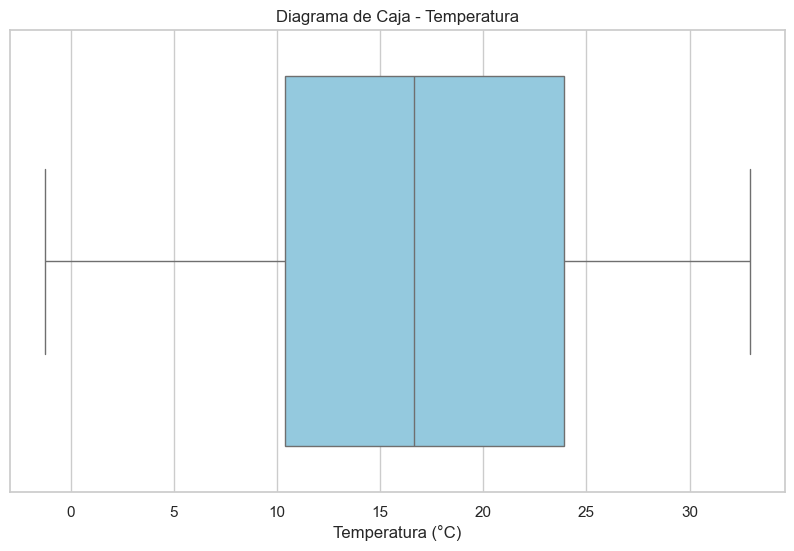


 Interpretación:
Los datos son relativamente homogéneos.


In [7]:
# ==========================================
# PARTE 2: MEDIDAS DE DISPERSIÓN 
# ==========================================

print("\n--- Análisis de Dispersión de la Temperatura ---")

# 1. Cálculo de las medidas
varianza = df["Temp"].var()
desviacion_std = df["Temp"].std()

# Cálculo del Rango Intercuartílico (IQR)
# Q1 = Percentil 25, Q3 = Percentil 75
Q1 = df["Temp"].quantile(0.25)
Q3 = df["Temp"].quantile(0.75)
IQR = Q3 - Q1

# Mostrar resultados numéricos
print(f"Variable: Temperatura diaria (°C)")
print(f"🔹 Varianza: {varianza:.2f}")
print(f"🔹 Desviación Estándar: {desviacion_std:.2f}")
print(f"🔹 Rango Intercuartílico (IQR): {IQR:.2f}")
print(f"   (Q1: {Q1:.2f} | Q3: {Q3:.2f})")

# 2. Visualización (Boxplot) para ver la dispersión y atípicos
plt.figure(figsize=(10, 6))
sns.boxplot(x=df["Temp"], color="skyblue")
plt.title("Diagrama de Caja - Temperatura")
plt.xlabel("Temperatura (°C)")
plt.show()

# Interpretación rápida automática
print("\n Interpretación:")
if desviacion_std > 10:
    print("Los datos están MUY dispersos (hay climas muy extremos entre ciudades).")
else:
    print("Los datos son relativamente homogéneos.")

In [ ]:
# ==========================================
# PARTE 3: FORMA DE LA DISTRIBUCIÓN
# ==========================================

#Varibales analizadas: Temperatura y Humedad

import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

# Cargar datos
df = pd.read_csv("clima_datos.csv")

# Variables
variables = ["Temp", "Humedad"]

print("--- MEDIDAS DE FORMA DE LA DISTRIBUCIÓN ---\n")

for var in variables:
    asimetria = stats.skew(df[var])
    curtosis = stats.kurtosis(df[var])  # exceso de curtosis
    
    print(f"Variable: {var}")
    print(f"  🔹 Asimetría: {asimetria:.3f}")
    print(f"  🔹 Curtosis: {curtosis:.3f}")
    
    # Interpretación automática
    if asimetria > 0:
        print("  ➤ Distribución asimétrica positiva (cola a la derecha)")
    elif asimetria < 0:
        print("  ➤ Distribución asimétrica negativa (cola a la izquierda)")
    else:
        print("  ➤ Distribución simétrica")
    
    if curtosis > 0:
        print("  ➤ Distribución leptocúrtica (colas pesadas)")
    elif curtosis < 0:
        print("  ➤ Distribución platicúrtica (colas ligeras)")
    else:
        print("  ➤ Distribución mesocúrtica (similar a la normal)")
    
    print("-" * 50)


In [ ]:
# Visualización de la forma de la distribución

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(df["Temp"], kde=True, color="skyblue")
plt.title("Distribución de la Temperatura")

plt.subplot(1, 2, 2)
sns.histplot(df["Humedad"], kde=True, color="salmon")
plt.title("Distribución de la Humedad")

plt.tight_layout()
plt.show()


### Interpretación

La asimetría permite identificar si la distribución presenta una cola más pronunciada hacia valores altos o bajos.  
La curtosis indica el grado de concentración de los datos alrededor de la media y el peso de las colas.

En el contexto climático, estas medidas ayudan a identificar la presencia de valores extremos y a evaluar si los datos se aproximan a una distribución normal, lo cual es relevante para la aplicación de pruebas estadísticas posteriores.


--- ANÁLISIS DE NORMALIDAD ---
P-valor obtenido: 0.0710
Resultado: Los datos son NORMALES (Usar pruebas paramétricas)


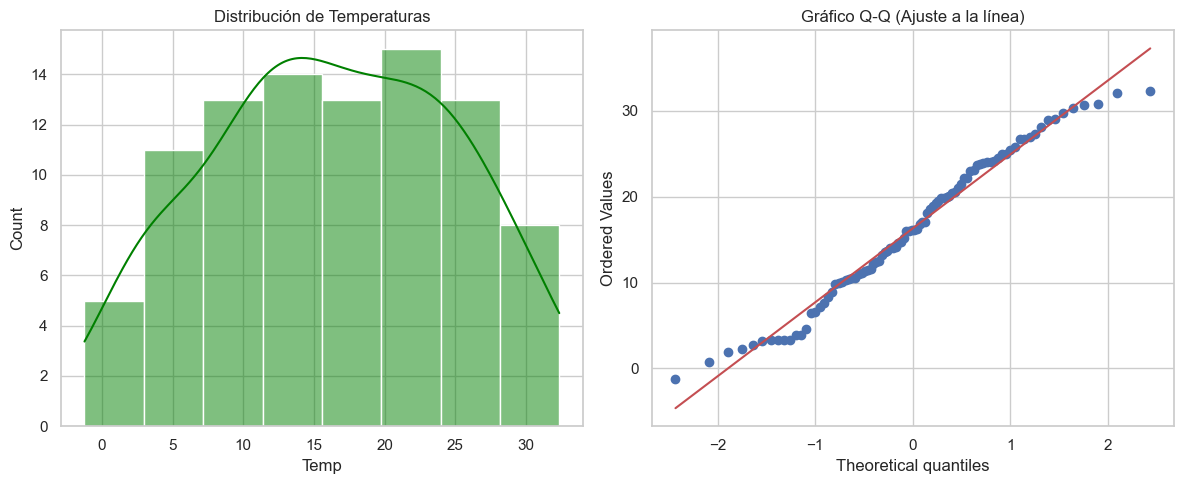

In [3]:
# ==========================================
# PARTE 4: SUPUESTO DE NORMALIDAD
# ==========================================
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Cargar los datos generados por el integrante 1
try:
    df = pd.read_csv("clima_datos.csv")
    datos_temp = df["Temp"]

    print("--- ANÁLISIS DE NORMALIDAD ---")

    # 2. Prueba de Shapiro-Wilk
    stat, p_valor = stats.shapiro(datos_temp)
    print(f"P-valor obtenido: {p_valor:.4f}")

    # 3. Veredicto técnico
    if p_valor > 0.05:
        resultado = "NORMALES"
        print("Resultado: Los datos son NORMALES (Usar pruebas paramétricas)")
    else:
        resultado = "NO NORMALES"
        print("Resultado: Los datos NO son normales (Usar pruebas NO paramétricas)")

    # 4. Gráficas visuales
    plt.figure(figsize=(12, 5))

    # Histograma para ver la "campana"
    plt.subplot(1, 2, 1)
    sns.histplot(datos_temp, kde=True, color="green")
    plt.title("Distribución de Temperaturas")

    # Gráfico Q-Q para ver la alineación
    plt.subplot(1, 2, 2)
    stats.probplot(datos_temp, dist="norm", plot=plt)
    plt.title("Gráfico Q-Q (Ajuste a la línea)")

    plt.tight_layout()
    plt.show()

except FileNotFoundError:
    print("ERROR: Primero debes ejecutar la celda del Integrante 1 para generar el archivo CSV.")

In [8]:
# ==========================================
# PARTE 5: HOMOGENEIDAD DE VARIANZAS
# ==========================================
import requests
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import levene

def obtener_temperaturas(ciudad):
    url = f"https://api.openweathermap.org/data/2.5/forecast?q={ciudad}&appid={API_KEY}&units=metric"
    response = requests.get(url)
    data = response.json()

    temperaturas = []
    fechas = []

    for item in data['list']:
        temperaturas.append(item['main']['temp'])
        fechas.append(item['dt_txt'])

    df = pd.DataFrame({
        'Fecha': fechas,
        'Temperatura': temperaturas
    })

    return df

In [11]:
#Mostrando tabla sobre temperaturas en Lima
lima = obtener_temperaturas("Lima")
lima.head()

,Fecha,Temperatura
0,2025-12-18 15:00:00,19.14
1,2025-12-18 18:00:00,21.29
2,2025-12-18 21:00:00,20.64
3,2025-12-19 00:00:00,21.63
4,2025-12-19 03:00:00,19.65


In [12]:
#Mostrando tabla sobre temperatuas en Trujillo
trujillo = obtener_temperaturas("Trujillo")
trujillo.head()

,Fecha,Temperatura
0,2025-12-18 15:00:00,19.98
1,2025-12-18 18:00:00,20.99
2,2025-12-18 21:00:00,21.27
3,2025-12-19 00:00:00,19.98
4,2025-12-19 03:00:00,19.40


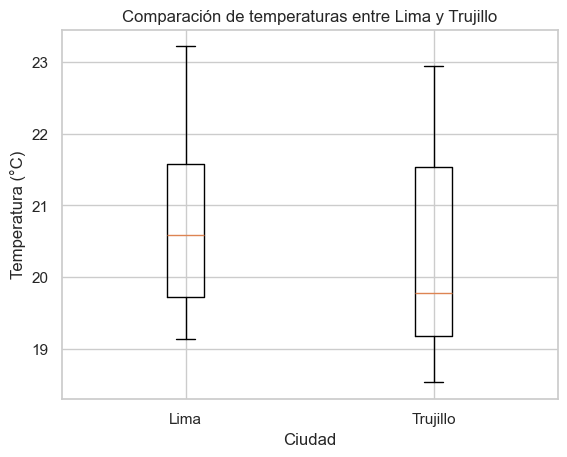

In [13]:
#Creamos un boxplot para obtener una comparación visual
plt.boxplot(
    [lima["Temperatura"], trujillo["Temperatura"]],
    tick_labels=["Lima", "Trujillo"]
);

plt.xlabel("Ciudad")
plt.ylabel("Temperatura (°C)")
plt.title("Comparación de temperaturas entre Lima y Trujillo")

plt.show()

In [14]:
# Prueba de Levene
from scipy.stats import levene

stat, p_value = levene(
    lima["Temperatura"],
    trujillo["Temperatura"]
)

print("Estadístico de Levene:", stat)
print("p-value:", p_value)

Estadístico de Levene: 0.1070267266802485
p-value: 0.7444312512338592


### Interpretación de la Prueba de Levene – Homogeneidad de varianzas

La prueba de Levene se utilizó para evaluar la homogeneidad de varianzas entre las
temperaturas de Lima y Trujillo.

El valor p obtenido es mayor que el nivel de significancia α = 0.05, por lo que
no se rechaza la hipótesis nula. Esto indica que no existen diferencias
estadísticamente significativas entre las varianzas de las temperaturas de ambas
ciudades.

Por lo tanto, se cumple el supuesto de homogeneidad de varianzas.



--- COMPARACIÓN DE MEDIAS (Lima vs. Trujillo) ---
P-valor Normalidad (Lima): 0.0056 -> NO NORMAL
P-valor Normalidad (Trujillo): 0.0004 -> NO NORMAL
Decisión: Se usará Mann–Whitney U (No Paramétrica)

--- RESULTADOS DE LA PRUEBA ---
Prueba Aplicada: Mann–Whitney U
Estadístico (M): 1024.0000
P-valor Final: 0.0315
Veredicto: Diferencia significativa


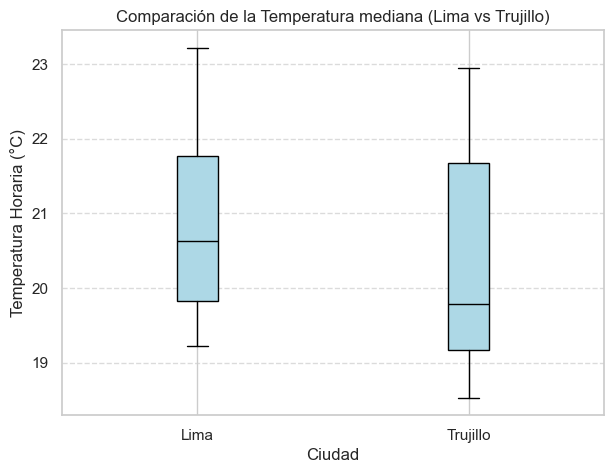

In [16]:
import pandas as pd
import scipy.stats as stats
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests
import time

# ======================================================================
# CONFIGURACIÓN Y FUNCIÓN DE EXTRACCIÓN
# ======================================================================

API_KEY = "170265dcc664b1396cd1d6be03d32bc0"
ALFA = 0.05
CIUDAD_A = "Lima"
CIUDAD_B = "Trujillo"

def obtener_temperaturas(ciudad):
    """Extrae las temperaturas horarias (muestra grande) del forecast y retorna un DataFrame."""
    # NOTA: Usamos 'lang=es' en la URL para mantener la consistencia con versiones anteriores, aunque no afecta a los datos numéricos.
    url = f"https://api.openweathermap.org/data/2.5/forecast?q={ciudad}&appid={API_KEY}&units=metric&lang=es"
    try:
        response = requests.get(url)
        response.raise_for_status() 
        data = response.json()
        
        temperaturas = [item['main']['temp'] for item in data.get('list', [])]
        fechas = [item['dt_txt'] for item in data.get('list', [])]

        df = pd.DataFrame({
            'Fecha': fechas,
            'Temperatura': temperaturas
        })
        return df
    except Exception as e:
        # Manejo de error si la API falla
        print(f"ERROR: No se pudieron obtener datos para {ciudad}. {e}")
        return pd.DataFrame({'Temperatura': []})


# ======================================================================
# PARTE 6: COMPARACIÓN DE MEDIAS
# ======================================================================

# 1. Obtención de los datos y preparación de las muestras
try:
    df_lima = obtener_temperaturas(CIUDAD_A)
    time.sleep(1) 
    df_trujillo = obtener_temperaturas(CIUDAD_B)

    # El array de temperaturas es lo que necesitamos para las pruebas estadísticas
    temperatura_lima = df_lima['Temperatura'].values
    temperatura_trujillo = df_trujillo['Temperatura'].values

    if len(temperatura_lima) < 5 or len(temperatura_trujillo) < 5:
        raise ValueError("Muestras insuficientes para pruebas estadísticas (n < 5).")

    print("\n--- COMPARACIÓN DE MEDIAS (Lima vs. Trujillo) ---")

    # 2. EVALUACIÓN DE SUPUESTOS (P4: Normalidad y P5: Varianzas)
    
    # 2a. Normalidad (P4) - Shapiro-Wilk
    _, p_norm_a = stats.shapiro(temperatura_lima)
    _, p_norm_b = stats.shapiro(temperatura_trujillo)
    es_normal = (p_norm_a > ALFA) and (p_norm_b > ALFA)

    print(f"P-valor Normalidad ({CIUDAD_A}): {p_norm_a:.4f} -> {'NORMAL' if p_norm_a > ALFA else 'NO NORMAL'}")
    print(f"P-valor Normalidad ({CIUDAD_B}): {p_norm_b:.4f} -> {'NORMAL' if p_norm_b > ALFA else 'NO NORMAL'}")

    # 2b. Homogeneidad (P5) - Solo si son normales
    equal_var_param = False
    if es_normal:
        _, p_leven = stats.levene(temperatura_lima, temperatura_trujillo, center='median')
        equal_var_param = p_leven > ALFA
        print(f"P-valor Levene (P5): {p_leven:.4f} -> {'HOMOGÉNEAS' if equal_var_param else 'HETEROGÉNEAS'}")
    else:
        print("Decisión: Se usará Mann–Whitney U (No Paramétrica)")

    # 3. PRUEBA DE HIPÓTESIS (P6)

    if es_normal:
        # Prueba Paramétrica: t de Student
        prueba_usada = f"t de Student ({'Varianzas Iguales' if equal_var_param else 'Welch'})"
        stat, p_final = stats.ttest_ind(temperatura_lima, temperatura_trujillo, equal_var=equal_var_param)
        metric_name = "media"
    else:
        # Prueba No Paramétrica: Mann-Whitney U
        prueba_usada = "Mann–Whitney U"
        stat, p_final = stats.mannwhitneyu(temperatura_lima, temperatura_trujillo)
        metric_name = "mediana"

    # 4. Veredicto técnico
    print("\n--- RESULTADOS DE LA PRUEBA ---")
    print(f"Prueba Aplicada: {prueba_usada}")
    print(f"Estadístico ({prueba_usada[0]}): {stat:.4f}")
    print(f"P-valor Final: {p_final:.4f}")
    print(f"Veredicto: {'Diferencia significativa' if p_final < ALFA else 'No hay diferencia significativa'}")


    # 5. Gráfico visual (Boxplot para comparación)
    plt.figure(figsize=(7, 5))
    plt.boxplot(
        [temperatura_lima, temperatura_trujillo],
        patch_artist=True,
        medianprops={"color": "black"},
        boxprops={"facecolor": "lightblue"}
    )
    plt.xticks([1, 2], [CIUDAD_A, CIUDAD_B])
    plt.xlabel("Ciudad")
    plt.ylabel(f"Temperatura Horaria (°C)")
    plt.title(f"Comparación de la Temperatura {metric_name} ({CIUDAD_A} vs {CIUDAD_B})")
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show() 

except Exception as e:
    print(f"ERROR: No se pudo completar la Parte 6. Detalle: {e}")